# Greenland Crust Deformation
### Long Term Mean, Distributions, Signal-to-Noise Ratio
Code by Diego R. Varela Lugardo. Mentor: Surendra Adhikari

## Libraries
All libraries used thorugh the code

In [14]:
import sys

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

import numpy as np
import scipy
import scipy.signal
import pandas as pd
import datetime
from datetime import timedelta
from netCDF4 import Dataset
import xarray as xr

import os
from scipy.stats import pearsonr

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.colors as mpcolors
import matplotlib.cm as cm
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles
import regionmask


from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from scipy.ndimage import label as cc_label

import imageio



## Helper Functions

In [2]:
data_folder = 'data/ENU_v2' # path to the folder with the data 

# Loads the Metadata for all the station (latitude, longitude, and elevation)
StationMetaData = df = pd.read_csv('data/GreenlandStations.csv')

def get_data(location):
    file_name = str(location) + '.ENU.txt'
    path = os.path.join(data_folder, file_name)

    if os.path.isfile(path):
        data = np.loadtxt(path, skiprows=2)
    else:
        file_name = str(location) + '_ENU.txt'
        path = os.path.join(data_folder, file_name)

        if os.path.isfile(path):
            data = np.loadtxt(path, skiprows=2)
        else:
            raise FileNotFoundError(f"Neither '{location}.ENU.txt' nor '{location}_ENU.txt' found in {data_folder}")
    return data

def decimal_year_to_date(decimal_year):
    """
    Converts a decimal year to a datetime.date object.
    """
    year = int(decimal_year)
    fractional_part = decimal_year - year

    # Determine if it's a leap year for accurate day calculation
    is_leap = (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)
    days_in_year = 366 if is_leap else 365

    # Calculate the number of days from the start of the year
    days_offset = fractional_part * days_in_year

    # Create a datetime object for January 1st of that year
    start_of_year = datetime.date(year, 1, 1)

    # Add the calculated offset in days
    result_date = start_of_year + datetime.timedelta(days=days_offset)

    return result_date

def doy_to_angle(doy):
    radians = doy * 2 * np.pi / 365
    mean_angle = np.arctan2(np.mean(np.sin(radians)), np.mean(np.cos(radians)))
    cos = np.cos(mean_angle)
    return(cos)

def circular_mean(degrees):
    radians = np.deg2rad(np.array(degrees) * 360/365)
    mean_angle = np.arctan2(np.mean(np.sin(radians)), np.mean(np.cos(radians)))
    mean_angle = np.rad2deg(mean_angle) * 365/360
    if mean_angle < 0:
        mean_angle += 365
    return mean_angle

MAX_GAP_DAYS = 30 

def find_longest_continuous_segment(dates, max_gap_days=30):
    # Ensure dates are sorted
    dates = np.sort(dates)
    segments = []
    current_segment = [dates[0]]

    for i in range(1, len(dates)):
        if (dates[i] - dates[i-1]).days <= max_gap_days:
            current_segment.append(dates[i])
        else:
            segments.append(current_segment)
            current_segment = [dates[i]]
    segments.append(current_segment)

    # Return the longest continuous segment
    return max(segments, key=len)

def InterpRA(data, detrend, INTERP_LIMIT, wdays):   
    time = data[:, 0]

    if detrend:   
        data[:, 1:4] = scipy.signal.detrend(data[:, 1:4], axis=0)
        
    # Convert decimal year to datetime
    converted_dates = np.array([decimal_year_to_date(dy) for dy in time])
    df = pd.DataFrame({'Date': pd.to_datetime(converted_dates)})
    df.set_index('Date', inplace=True)

    df['East'] = data[:, 1]
    df['North'] = data[:, 2]
    df['Vertical'] = data[:, 3]
    df['Horizontal'] =  np.sqrt(data[:, 1] ** 2 + data[:, 2] **2)
    df['3DDisp'] = np.cbrt(data[:, 1] ** 2 + data[:, 2] **2 + data[:, 3] **2)

    df['year'] = df.index.year
    df['doy'] = df.index.dayofyear

    filled_list = []
    for year, group in df.groupby('year'):
        # Determine if leap year
        is_leap = (pd.Timestamp(f'{year}-12-31').is_leap_year)
        days_in_year = 366 if is_leap else 365

        # Create full day-of-year range
        full_range = pd.DataFrame({'doy': np.arange(1, days_in_year + 1)})
        full_range['year'] = year

        # Merge to include missing days as NaN
        group = full_range.merge(group, on=['year', 'doy'], how='left')

        # Remove duplicates by averaging
        group = group.groupby(['year', 'doy'], as_index=False).mean()

        # Restore datetime index
        group['Date'] = pd.to_datetime(
            group['year'].astype(str) + '-' + group['doy'].astype(str),
            format='%Y-%j',
            errors='coerce'
        )
        group = group.set_index('Date').sort_index()

        # 🔹 Interpolate only small gaps
        for col in ['East', 'North', 'Vertical', 'Horizontal', '3DDisp']:
            group[col] = group[col].interpolate(
                method="time", limit=INTERP_LIMIT, limit_direction="both"
            )

        filled_list.append(group)

        
    # Concatenate all years
    df = pd.concat(filled_list).sort_index()
    
    # Apply rolling mean smoothing
    df_rolling = df.rolling(
        window=wdays, 
        center=True, 
        min_periods=wdays - int(wdays / 5)
    ).mean()
    df_rolling = df_rolling.dropna()

    # Remove Feb 29 for consistency
    df_rolling = df_rolling[df_rolling.index.strftime('%m-%d') != '02-29']
    
    # Reattach year, day of year, and month_day columns
    df_rolling['year'] = df_rolling.index.year
    df_rolling['month_day'] = df_rolling.index.strftime('%m-%d')
    df_rolling['doy'] = df_rolling.index.dayofyear

    leap_mask = df_rolling.index.is_leap_year & (df_rolling.index.month > 2)
    df_rolling.loc[leap_mask, 'doy'] -= 1
    
    return df_rolling

## Long Term Mean CSV creation
The code initializes with five different variables that will be utilized in the helper functions. 
1. The code retrieves the raw data, extracting the time component  and transforming it from decimal to normal format. 
2. The code searches for the longest 'continuous' segment (maximum gap days are controlled by MAX_GAP_DAYS variable). 
3. New Data Array is produced by masking the raw data to get the longest 'continuous' segment.
4. Data is passed through InterpRA function. The function does the following:
    - If Detrend = True, it linearly detrends the data using scipy.signal
    - Displacement and Error Data is extracted. Five timeseries are created for the displacement vectors: East, North, Vertical, Horizontal, 3DDisp (cubic root of the sum of the 1D displacement vectors).
    - Linearly Interpolates missing values (variable here to set maximum of days)
    - Rolling Average is produced
    - Nan values are dropped 
    - February 29 is eliminated so that all years have 365 days
    - New Dataset is returned
5. If a specific day has less data points that accepted (min_years_per_doy), it gets masked.
6. Long Term Mean (LTM) and Standard Deviation (StDevs) are computed for every day of the year for all five components.
7. A rolling average (3 day window) is applied to the resultant LTM to smooth out. 
8. LTM and StDevs are exported as a single file

In [3]:
stations_names_with_data, metadata_records = [], []

MAX_GAP_DAYS = 60        # Maximum gap acceptable between data
INTERP_LIMIT = 8         # Maximum of days to be interpolated
wdays = 30               # Rolling Average window (number of days considered in the average)
MIN_DAYS_PER_YEAR = 350  # Minimum days required to be considered as a full year. 
min_years_of_data = 3    # Minimum length of the continuous segment

Save = False

for station_name in StationMetaData.station:
    try:
        raw_data = get_data(station_name)
        time = raw_data[:, 0]
        converted_dates = np.array([decimal_year_to_date(dy) for dy in time])

        # Find longest continuous segment of data
        continuous_segment = find_longest_continuous_segment(
            converted_dates, max_gap_days=MAX_GAP_DAYS
        )

        if len(continuous_segment) < 365 * min_years_of_data:  # optional: skip if segment is too short
            print(f"  → Skipping {station_name}: continuous segment too short.")
            continue
        
        smdt = StationMetaData.loc[StationMetaData['station'] == station_name]
        lon = smdt.longitude.values[0]
        lat = smdt.latitude.values[0]

        metadata_records.append({
                    "station": station_name,
                    "lon": lon,
                    "lat": lat,
                })

        if Save is False:
            stations_names_with_data.append(station_name)
            continue

        # Filter both data and error to this segment
        mask = np.isin(converted_dates, continuous_segment)
        data = raw_data[mask, :]

        df_rolling = InterpRA(data, True, INTERP_LIMIT, wdays)

        valid_years = df_rolling.groupby('year').filter(
            lambda x: len(x) >= MIN_DAYS_PER_YEAR
        )['year'].unique()
        df_rolling = df_rolling[df_rolling['year'].isin(valid_years)]
        
        LTM = df_rolling.groupby('month_day')[['East', 'North', 'Vertical','Horizontal', '3DDisp']].mean()
        stds = df_rolling.groupby('month_day')[['East', 'North', 'Vertical','Horizontal', '3DDisp']].std()
        
        stds.columns = ['East_sd', 'North_sd', 'Vertical_sd','Horizontal_sd', '3DDisp_sd']
        LTM = LTM.join(stds)

        LTM[['East','North','Vertical', 'Horizontal', '3DDisp' ]] = (
            LTM[['East','North','Vertical', 'Horizontal', '3DDisp']].rolling(3, center=True, min_periods=1).mean()
        )

        # Save LTM for this station
        if Save is True:
            LTM.to_csv(f'/LTM/files/{station_name}_Daily{wdays}RollingLTM.csv', index=True)

        stations_names_with_data.append(station_name)

    except FileNotFoundError:
        print(f"  → File not found for station {station_name}. Skipping.")
        continue
    except Exception as e:
        print(f"  → Error processing station {station_name}: {e}")
        continue
df_MetaData = pd.DataFrame(metadata_records)

  → Skipping NGFJ: continuous segment too short.
  → File not found for station THU4. Skipping.
  → File not found for station QENU. Skipping.
  → File not found for station AAS2. Skipping.
  → Skipping EQNU: continuous segment too short.
  → Skipping SCOB: continuous segment too short.
  → File not found for station SCO4. Skipping.
  → File not found for station STNO. Skipping.
  → File not found for station QAQ2. Skipping.
  → File not found for station KLQ3. Skipping.
  → Skipping UPAK: continuous segment too short.
  → Skipping AVAN: continuous segment too short.
  → File not found for station THU3. Skipping.
  → Skipping NUNA: continuous segment too short.
  → File not found for station KSUT. Skipping.


In [4]:
np.shape(stations_names_with_data) ## Verify how many stations we actually have data

(61,)

## Plotting of the Data
Note that the StDev is quite big as there is a lot of fluctuation in the mean of every year (Multidecadal systems). This StDev is not as useful.

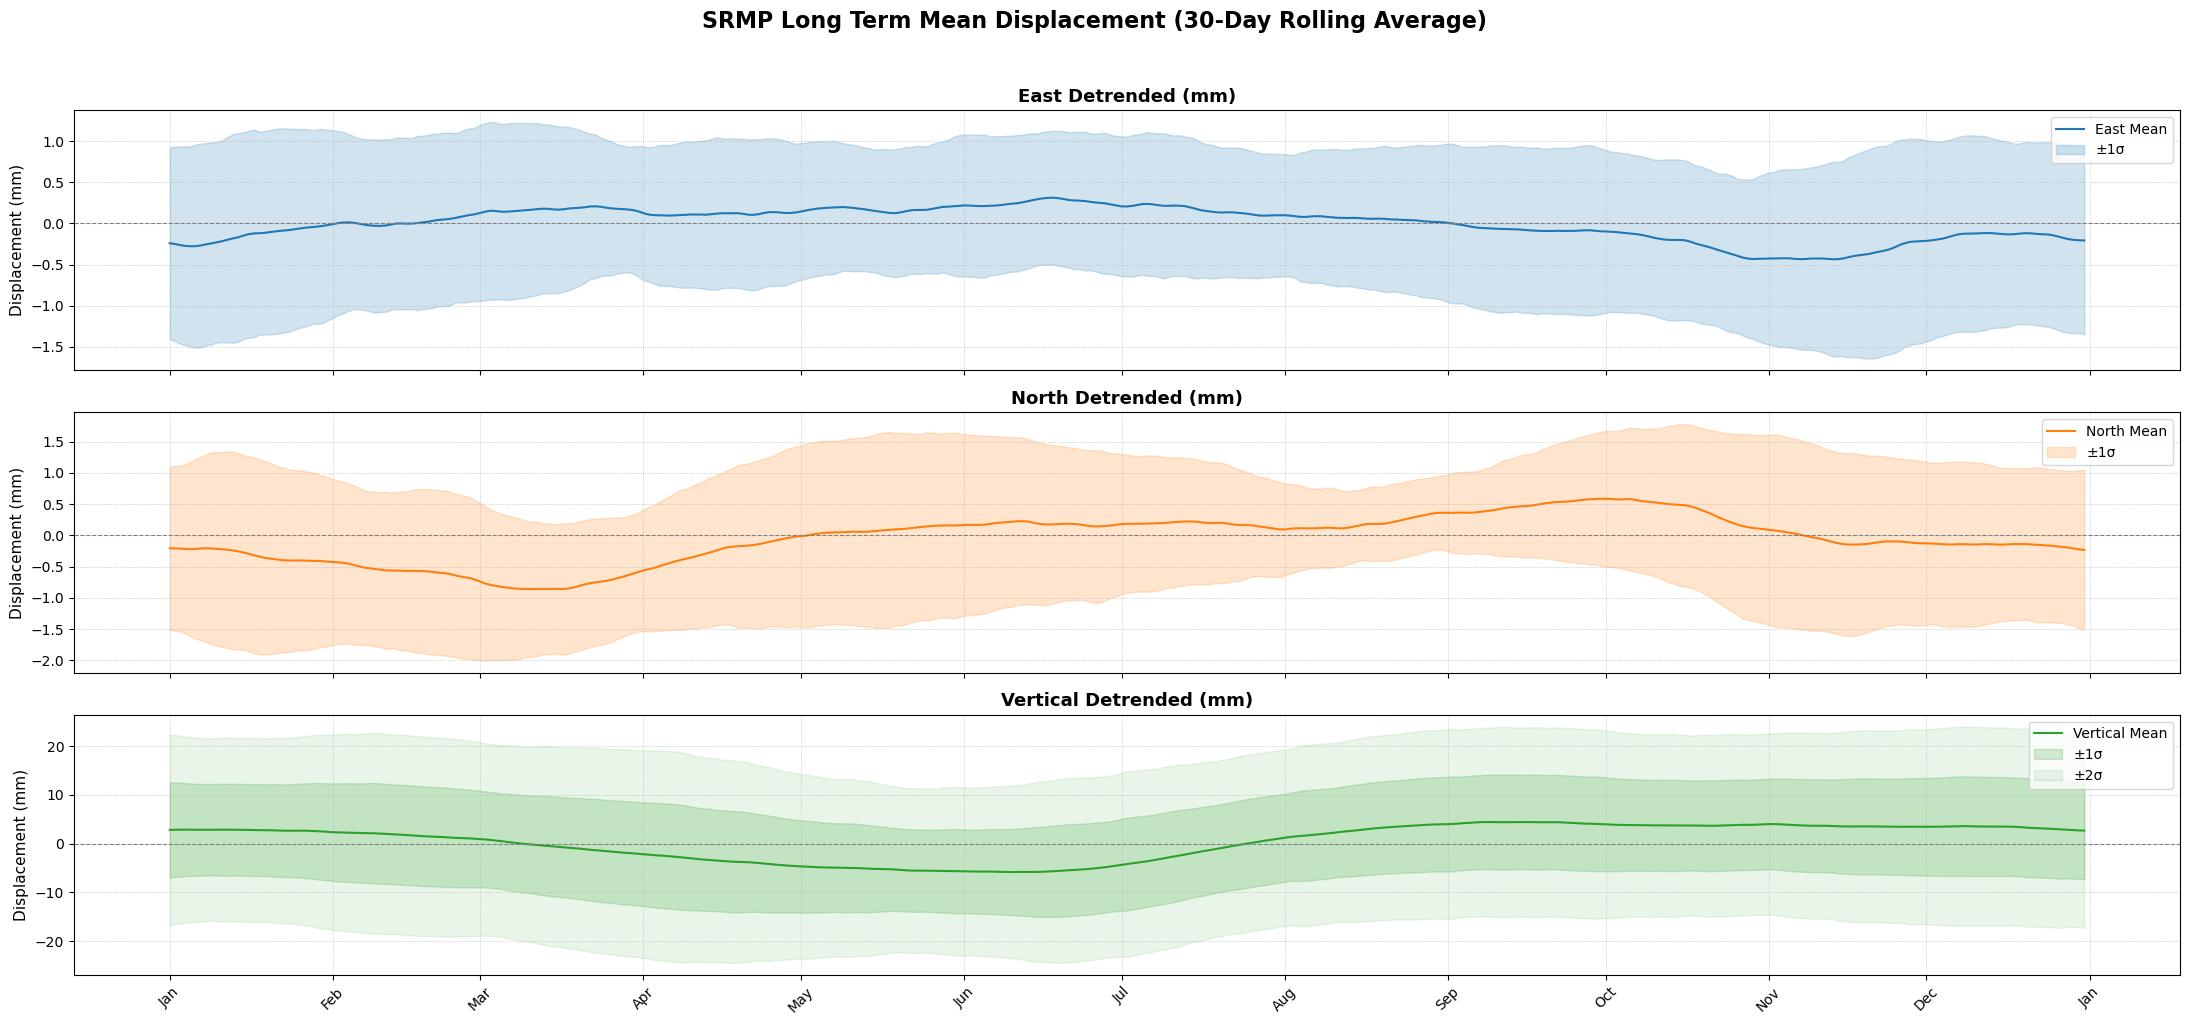

In [7]:
# Load data
station = 'SRMP'
climatology_daily = pd.read_csv('LTM/files/' + station + '_Daily30RollingLTM.csv') # ',{station_name}_Daily{wdays}RollingLTM.csv

# Set up the figure and subplots
fig, axs = plt.subplots(3, 1, figsize=(22, 10), sharex=True)

# Define colors
colors = {'East': '#1f77b4', 'North': '#ff7f0e', 'Vertical': '#2ca02c'}

# Plot each component
components = ['East', 'North', 'Vertical']
titles = ['East Detrended (mm)', 'North Detrended (mm)', 'Vertical Detrended (mm)']

for i, component in enumerate(components):
    ax = axs[i]
    sd = climatology_daily[component + '_sd']
    ax.plot(climatology_daily['month_day'], climatology_daily[component], label=f'{component.title()} Mean', color=colors[component])
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

    # 1-sigma shading
    ax.fill_between(climatology_daily['month_day'],
                    climatology_daily[component] - sd,
                    climatology_daily[component] + sd,
                    color=colors[component], alpha=0.2, label='±1σ')

    # 2-sigma only for 'up'
    if component == 'Vertical':
        ax.fill_between(climatology_daily['month_day'],
                        climatology_daily[component] - 2 * sd,
                        climatology_daily[component] + 2 * sd,
                        color=colors[component], alpha=0.1, label='±2σ')

    ax.set_title(titles[i], fontsize=13, weight='bold')
    ax.grid(True, linestyle=':', linewidth=0.5)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_ylabel('Displacement (mm)', fontsize=11)

# X-axis settings
#axs[-1].set_xlabel('Date (MM-DD)', fontsize=12)
axs[-1].xaxis.set_major_locator(mdates.MonthLocator())
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Rotate x labels
plt.setp(axs[-1].xaxis.get_majorticklabels(), rotation=45)

# Add overall title
fig.suptitle(f'{station} Long Term Mean Displacement (30-Day Rolling Average)', fontsize=16, weight='bold', y=1.02)

# Final layout tweaks
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## 'Compressed' Anomalies
To observe the 'seasonal' behavior and take out multi-year oscillations, the data is compressed so that every year has an average of zero. 
Each year is averaged and the average is substracted to the same year, plotting the anomaly to respect that year. 

In [ ]:
DispAll = ['Vertical', 'Horizontal', '3DDisp']

for station_name in stations_names_with_data:
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)  # 3 rows, 1 col

    legend_handles = []
    legend_labels = []
    n_years = 0  # counter

    for j, Disp in enumerate(DispAll):
        ax = axes[j]  # select subplot
        
        raw_data = get_data(station_name)
        INTERP_LIMIT = 3  
        wdays = 30
        rd_data = InterpRA(raw_data, True, INTERP_LIMIT, wdays )

        years = sorted(np.unique(rd_data.year))
        colormap = cm.get_cmap('viridis', len(years))

        ax.set_ylabel(f'{Disp} Displacement (mm)', fontsize=12)
        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.set_xlim(0, 365)

        days = np.arange(1, 366)
        all_years_df = []

        # Load LTM
        LTM = pd.read_csv('LTM/files/SRMP_Daily30RollingLTM.csv')
        LTM = LTM[Disp]
        offset_LTM = np.array(LTM - np.nanmean(LTM))

        for year in years:
            data = rd_data[rd_data['year'] == year].copy()
            if data[Disp].count() < 350:
                continue
            data[Disp] = data[Disp] - np.nanmean(data[Disp])
            all_years_df.append(data)

        if len(all_years_df) == 0:
            continue  # skip if no valid years

        all_years_df = pd.concat(all_years_df)
        STD = np.array(all_years_df.groupby('doy')[Disp].std())

        # update year count once (first subplot is enough)
        if j == 0:
            n_years = len(all_years_df['year'].unique())

        # bands
        upper1 = offset_LTM + STD
        lower1 = offset_LTM - STD
        upper2 = offset_LTM + STD * 2
        lower2 = offset_LTM - STD * 2
        upper15 = offset_LTM + STD * 1.8
        lower15 = offset_LTM - STD * 1.8

        # Plot mean and bands
        ax.plot(days, offset_LTM, lw=2, c='red', label='Mean')
        ax.fill_between(days, lower1, upper1, color='red', alpha=0.2, label='±1σ')
        #ax.fill_between(days, lower2, upper2, color='red', alpha=0.1, label='±2σ')

        # Collect handles for legend only once (first loop)
        if j == 0:
            handles, labels = ax.get_legend_handles_labels()
            legend_handles.extend(handles)
            legend_labels.extend(labels)

        for i, year in enumerate(sorted(all_years_df['year'].unique())):
            yr = all_years_df[all_years_df['year'] == year].set_index("doy")
            yr_disp = yr[Disp]
            idx = yr.index.values - 1  

            yr_upper = upper15[idx]
            yr_lower = lower15[idx]

            mask_upper = yr_disp.values > yr_upper
            mask_lower = yr_disp.values < yr_lower
            outside_frac = (mask_upper.sum() + mask_lower.sum()) / len(yr_disp)

            # if outside_frac >= 0.1:
            #     ax.plot(yr.index, yr_disp.values, lw=1.5, color=colormap(i), label=str(year))
            # else:
            #     ax.plot(yr.index, yr_disp.values, lw=1.0, color=colormap(i), alpha=0.1)

    # shared x-axis labels
    axes[-1].set_xlabel("Day of Year", fontsize=12)

    # use f-string for dynamic year count
    fig.suptitle(f'Detrended - Average Displacement at {station_name}\n n = {n_years} years',
                 fontsize=16, weight='bold')

    # One legend for all, at the bottom
    fig.legend(legend_handles, legend_labels,
               loc="lower center", ncol=len(legend_labels), frameon=True)

    plt.tight_layout(rect=[0.0, 0.02, .98, 1.005])  # extra space for legend + title
    filename = f'LTM/AverageDisplacement/AvgDisplacement_{station_name}_Anomalies.png'
    plt.savefig(filename, dpi=300)
    plt.close()

## Metrics
Calculate Amplitude, DoY of peak & minima, and correlation to the LTM. This uses the yearly anomaly data. It then plots it but does not store the values.

## Characteristic Map
First cell of code creates the metrics ploted (similar to a code before) and second one plots it. This code uses the LTM previously calculated to obtain the metrics.

In [8]:
DispAll = ['Vertical']
recordsavg = []

for station_name in stations_names_with_data:
    LTM = pd.read_csv(f'LTM/files/{station_name}_Daily30RollingLTM.csv')

    smdt = StationMetaData.loc[StationMetaData['station'] == station_name]
    lon, lat = smdt.longitude, smdt.latitude

    for Disp in DispAll:
        LTM_vals = LTM[Disp].values

        max_idx = np.argmax(LTM_vals)
        min_idx = np.argmin(LTM_vals)
        amp = np.max(LTM_vals) - np.min(LTM_vals)
        dt = np.abs(max_idx - min_idx)

        raw_data = get_data(station_name)
        INTERP_LIMIT = 8  
        wdays = 30
        rd_data = InterpRA(raw_data, True, INTERP_LIMIT, wdays )
        max_ay, min_ay, amp_ay, dt_ay = [], [], [], []

        years = sorted(np.unique(rd_data.year))

        for year in years:
            data = rd_data[rd_data['year'] == year].copy()
            if data[Disp].count() < 350:
                continue
            data = data[Disp] - np.nanmean(data[Disp])

            max_ay.append(np.argmax(data.values))
            min_ay.append(np.argmin(data.values))
            dt_ay.append(np.abs(np.argmax(data.values) - np.argmin(data.values) ))
            amp_ay.append(np.max(data.values) - np.min(data.values))

        STDpc_amp = np.std(amp_ay) / ( amp ) * 100
    
        STD_dt = np.std(dt_ay)
        STD_p = scipy.stats.circstd(max_ay, high=366, low=1) 
        STD_m = scipy.stats.circstd(min_ay, high=366, low=1)  
        

        recordsavg.append({
                    "station": station_name,
                    "lon": lon,
                    "lat": lat,
                    "disp": Disp,
                    "Amplitude": amp,
                    "Peak_DoY": max_idx,
                    "Min_DoY": min_idx,
                    "Time_MintoPeak": dt,
                    "Amplitude_StDev": STDpc_amp,
                    "Peak_DoY_StDev": STD_p,
                    "Min_DoY_StDev": STD_m,
                    "Time_MintoPeak_StDev" : STD_dt,
                    
                })
        
df_metricsavg = pd.DataFrame(recordsavg)

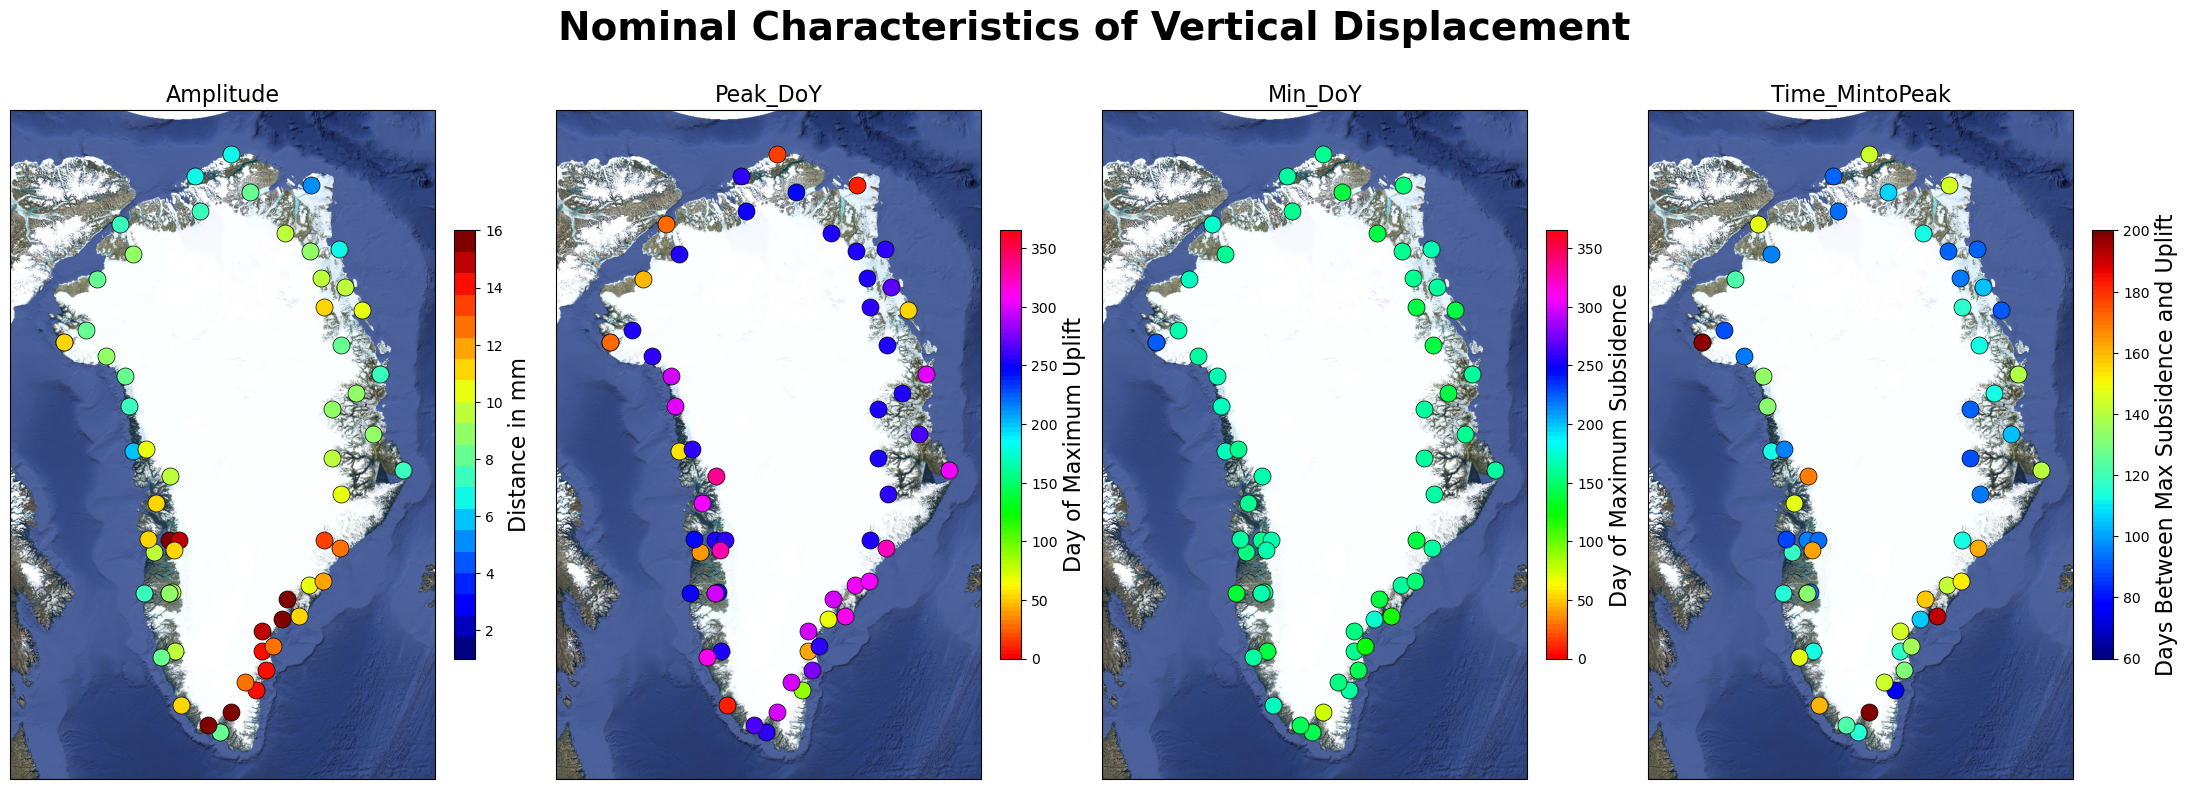

In [10]:
tiler = GoogleTiles(style="satellite") # Opens Satellite Image

fig, ax = plt.subplots(1,4, figsize=(22, 8.5), sharey=True, subplot_kw={'projection': ccrs.Stereographic(central_longitude=-50)}) ## Creates subplots

extent = [-65, -27, 58, 85]

Disp = 'Vertical'
Metrics = ['Amplitude', 'Peak_DoY', 'Min_DoY', 'Time_MintoPeak']
df_sub = df_metricsavg[(df_metricsavg["disp"] == Disp)] # Dataset opens
Labels = {'Amplitude_StDev': 'Percentage of LTM %', 'Peak_DoY_StDev': 'Standard Deviation in # Days', 'Min_DoY_StDev': 'Standard Deviation in # Days',
          'Amplitude': 'Distance in mm', 'Peak_DoY': 'Day of Maximum Uplift', 'Min_DoY': 'Day of Maximum Subsidence', 
          'Time_MintoPeak_StDev':'Days Between Max Subsidence and Uplift (StDev)', 'Time_MintoPeak' : 'Days Between Max Subsidence and Uplift'}

for a in ax:
    a.set_extent(extent, crs=ccrs.PlateCarree())  
    a.add_image(tiler, 6)

for i, Metric in enumerate(Metrics):
    if Metric == 'Amplitude':
            cmap = mpl.colormaps['jet'].resampled(20)
            vmin = 1
            vmax = 16
            norm = mpcolors.Normalize(vmin=vmin, vmax=vmax)

    elif Metric == 'Amplitude_StDev':
            cmap = mpl.colormaps['jet'].resampled(50)
            vmin = 1
            vmax = 100
            norm = mpcolors.Normalize(vmin=vmin, vmax=vmax)

    elif Metric in ['Peak_DoY_StDev', 'Min_DoY_StDev', 'Time_MintoPeak_StDev']:
        cmap = mpl.colormaps['jet'].resampled(70)
        vmin = 10
        vmax = 80
        norm = mpcolors.Normalize(vmin=vmin, vmax=vmax)

    elif Metric in ['Time_MintoPeak']:
        cmap = mpl.colormaps['jet'].resampled(100)
        vmin = 60
        vmax = 200
        norm = mpcolors.Normalize(vmin=vmin, vmax=vmax)

    else:
        cmap = mpl.colormaps['hsv'].resampled(100)
        vmin = 0
        vmax = 365
        norm = mpcolors.Normalize(vmin=vmin, vmax=vmax)

    for _, row in df_sub.iterrows():
        ax[i].scatter(row["lon"], row["lat"], c=[row[Metric]], cmap=cmap, norm=norm,
        s=150, edgecolor="k",linewidth=0.5, alpha = 1,transform=ccrs.PlateCarree())

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  
    cbar = fig.colorbar(sm, ax=ax[i], orientation="vertical", fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel(Labels[Metric], fontsize=16)

    ax[i].set_title(f'{Metric}', fontsize=16)

fig.suptitle('Nominal Characteristics of Vertical Displacement', fontsize=28, weight='demibold')

fig.tight_layout(pad=1.14)

plt.savefig('VerticalNominalCharacteristics.png', dpi=300)
plt.show()

In [14]:
datavert = df_metricsavg[df_metricsavg['disp'] == 'Vertical']

datavertwooutliers = df_metricsavg[
    (df_metricsavg['disp'] == 'Vertical') & 
    (~df_metricsavg['station'].isin(['ILUL', 'THU1', 'NNVN']))
]



## Data Distribution

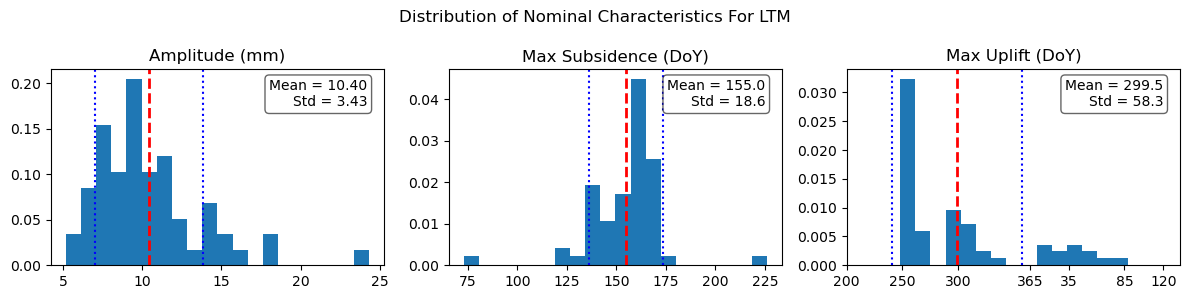

In [13]:
peak_doy_shifted = datavert['Peak_DoY'].copy()
peak_doy_shifted = peak_doy_shifted.apply(lambda x: x+365 if x < 165 else x)

fig, ax = plt.subplots(1,3, figsize=(12, 3)) ## Creates subplots

# ---- Amplitude ----
ax[0].hist(datavert['Amplitude'], bins=20, density=True)
ax[0].set_title('Amplitude (mm)')
mean_amp = datavert['Amplitude'].mean()
std_amp = datavert['Amplitude'].std()

# Lines
ax[0].axvline(mean_amp, color="red", linestyle="--", linewidth=2, label="Mean")
ax[0].axvline(mean_amp - std_amp, color="blue", linestyle=":", linewidth=1.5, label="±1 Std")
ax[0].axvline(mean_amp + std_amp, color="blue", linestyle=":", linewidth=1.5)

# Text
ax[0].text(0.95, 0.95, f"Mean = {mean_amp:.2f}\nStd = {std_amp:.2f}",
           transform=ax[0].transAxes, ha="right", va="top", fontsize=10,
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.6))

# ---- Min_DoY ----
ax[1].hist(datavert['Min_DoY'], bins=20, density=True)
ax[1].set_title('Max Subsidence (DoY)')
mean_min = datavert['Min_DoY'].mean()
std_min = datavert['Min_DoY'].std()

ax[1].axvline(mean_min, color="red", linestyle="--", linewidth=2, label="Mean")
ax[1].axvline(mean_min - std_min, color="blue", linestyle=":", linewidth=1.5, label="±1 Std")
ax[1].axvline(mean_min + std_min, color="blue", linestyle=":", linewidth=1.5)

ax[1].text(0.95, 0.95, f"Mean = {mean_min:.1f}\nStd = {std_min:.1f}",
           transform=ax[1].transAxes, ha="right", va="top", fontsize=10,
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.6))

# ---- Peak_DoY (shifted) ----
ax[2].hist(peak_doy_shifted, bins=15, density=True)
ax[2].set_title('Max Uplift (DoY)')
mean_peak = peak_doy_shifted.mean()
std_peak = peak_doy_shifted.std()

ax[2].axvline(mean_peak, color="red", linestyle="--", linewidth=2, label="Mean")
ax[2].axvline((mean_peak - std_peak),
              color="blue", linestyle=":", linewidth=1.5, label="±1 Std")
ax[2].axvline((mean_peak + std_peak) ,
              color="blue", linestyle=":", linewidth=1.5)

ax[2].text(0.95, 0.95, f"Mean = {mean_peak:.1f}\nStd = {std_peak:.1f}",
           transform=ax[2].transAxes, ha="right", va="top", fontsize=10,
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.6))

# Axis wrapping for Peak_DoY
ax[2].set_xlim(200, 500)  
xticks = [200, 250, 300, 365, 400, 450, 485]
xtick_labels = [200, 250, 300, 365, 35, 85, 120] 
ax[2].set_xticks(xticks)
ax[2].set_xticklabels(xtick_labels)

plt.suptitle('Distribution of Nominal Characteristics For LTM')
plt.tight_layout()
plt.show()


## Distribution using data of all years, all stations

In [16]:
DispAll = ['Vertical']
recordsay = []

for station_name in stations_names_with_data:
    LTM = pd.read_csv(f'LTM/files/{station_name}_Daily30RollingLTM.csv')

    smdt = StationMetaData.loc[StationMetaData['station'] == station_name]
    lon, lat = smdt.longitude, smdt.latitude

    for Disp in DispAll:
        raw_data = get_data(station_name)
        INTERP_LIMIT = 8  
        wdays = 30
        rd_data = InterpRA(raw_data, True, INTERP_LIMIT, wdays)

        max_ay, min_ay, amp_ay, dt_ay = [], [], [], []

        years = sorted(np.unique(rd_data.year))

        for year in years:
            data = rd_data[rd_data['year'] == year].copy()

            if data[Disp].count() < 350:
                continue
            data = data[Disp] - np.nanmean(data[Disp])

            recordsay.append({
                        "station": station_name,
                        "lon": lon,
                        "lat": lat,
                        "disp": Disp,
                        "year": year,
                        "Amplitude": np.max(data.values) - np.min(data.values),
                        "Peak_DoY": np.argmax(data.values),
                        "Min_DoY": np.argmin(data.values),
                        "Time_MintoPeak": np.abs(np.argmax(data.values) - np.argmin(data.values) ),
                    })
            
df_metricsay = pd.DataFrame(recordsay)
df_metricsay.to_csv('data/AllYearsMetrics.csv', index=False)

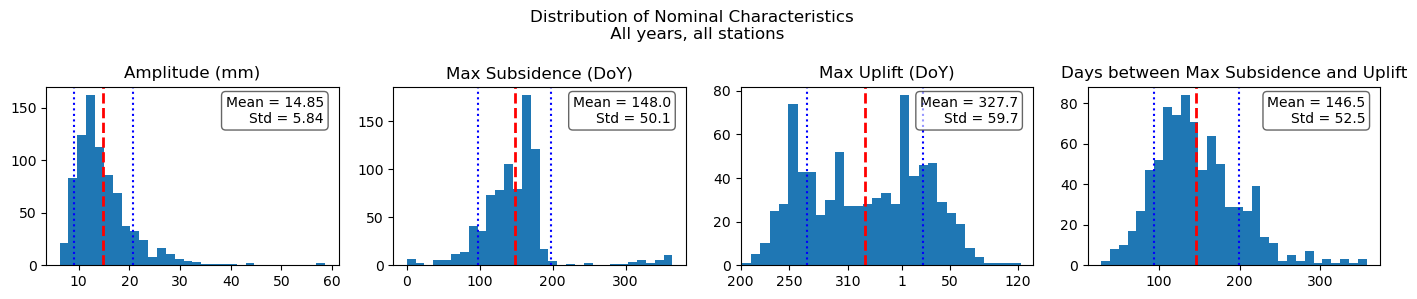

In [17]:
data = df_metricsay
bins = 30

peak_doy_shifted = data['Peak_DoY'].copy()
peak_doy_shifted = peak_doy_shifted.apply(lambda x: x+365 if x < 165 else x)

fig, ax = plt.subplots(1,4, figsize=(14, 3)) ## Creates subplots

# ---- Amplitude ----
ax[0].hist(data['Amplitude'], bins=bins,)
ax[0].set_title('Amplitude (mm)')
mean_amp = data['Amplitude'].mean()
std_amp = data['Amplitude'].std()

# Lines
ax[0].axvline(mean_amp, color="red", linestyle="--", linewidth=2, label="Mean")
ax[0].axvline(mean_amp - std_amp, color="blue", linestyle=":", linewidth=1.5, label="±1 Std")
ax[0].axvline(mean_amp + std_amp, color="blue", linestyle=":", linewidth=1.5)

# Text
ax[0].text(0.95, 0.95, f"Mean = {mean_amp:.2f}\nStd = {std_amp:.2f}",
           transform=ax[0].transAxes, ha="right", va="top", fontsize=10,
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.6))

# ---- Min_DoY ----
ax[1].hist(data['Min_DoY'], bins=bins)
ax[1].set_title('Max Subsidence (DoY)')
mean_min = data['Min_DoY'].mean()
std_min = data['Min_DoY'].std()

ax[1].axvline(mean_min, color="red", linestyle="--", linewidth=2, label="Mean")
ax[1].axvline(mean_min - std_min, color="blue", linestyle=":", linewidth=1.5, label="±1 Std")
ax[1].axvline(mean_min + std_min, color="blue", linestyle=":", linewidth=1.5)

ax[1].text(0.95, 0.95, f"Mean = {mean_min:.1f}\nStd = {std_min:.1f}",
           transform=ax[1].transAxes, ha="right", va="top", fontsize=10,
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.6))

# ---- Peak_DoY (shifted) ----
ax[2].hist(peak_doy_shifted, bins=bins)
ax[2].set_title('Max Uplift (DoY)')
mean_peak = peak_doy_shifted.mean()
std_peak = peak_doy_shifted.std()

ax[2].axvline(mean_peak, color="red", linestyle="--", linewidth=2, label="Mean")
ax[2].axvline((mean_peak - std_peak),
              color="blue", linestyle=":", linewidth=1.5, label="±1 Std")
ax[2].axvline((mean_peak + std_peak),
              color="blue", linestyle=":", linewidth=1.5)

ax[2].text(0.95, 0.95, f"Mean = {mean_peak:.1f}\nStd = {std_peak:.1f}",
           transform=ax[2].transAxes, ha="right", va="top", fontsize=10,
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.6))

# Axis wrapping for Peak_DoY
ax[2].set_xlim(200, 500)  
xticks = [200, 250, 310, 366, 365+50, 485]
xtick_labels = [200, 250, 310 , 1, 50, 120] 
ax[2].set_xticks(xticks)
ax[2].set_xticklabels(xtick_labels)

# ---- Min_DoY ----
ax[3].hist(data['Time_MintoPeak'], bins=bins)
ax[3].set_title('Days between Max Subsidence and Uplift')
mean_min = data['Time_MintoPeak'].mean()
std_min = data['Time_MintoPeak'].std()

ax[3].axvline(mean_min, color="red", linestyle="--", linewidth=2, label="Mean")
ax[3].axvline(mean_min - std_min, color="blue", linestyle=":", linewidth=1.5, label="±1 Std")
ax[3].axvline(mean_min + std_min, color="blue", linestyle=":", linewidth=1.5)

ax[3].text(0.95, 0.95, f"Mean = {mean_min:.1f}\nStd = {std_min:.1f}",
           transform=ax[3].transAxes, ha="right", va="top", fontsize=10,
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.6))

plt.suptitle('Distribution of Nominal Characteristics \n All years, all stations')
plt.tight_layout()
plt.show()

## Grace Implementation
By utilizing Grace Altimetry Data on the GrIS, we can signal out regions that have faced more water loss (ice) than others. 

In [ ]:
## Grace Trend for all of the GrIS
GraceData = pd.read_csv("data/GraceGrIS.csv",  parse_dates=["DateTime"])
GraceData = GraceData.set_index("DateTime")
GraceData = GraceData.rename(columns={
    "Water Equivalent Thickness – Land (GRACE, GRACE-FO JPL)": "wet" })
time = GraceData.index
GraceDet = scipy.signal.detrend(GraceData, axis=0)

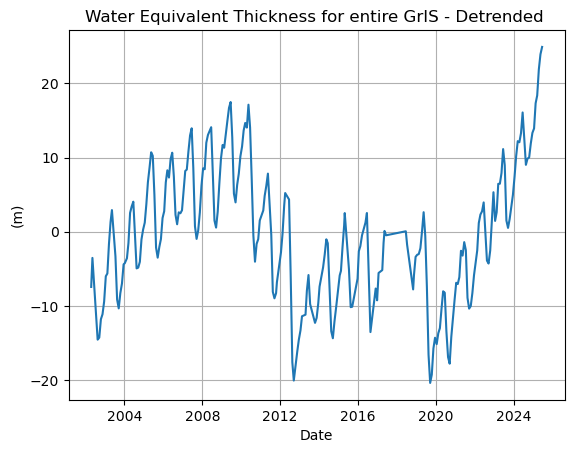

In [20]:
plt.plot(time, GraceDet)
plt.title('Water Equivalent Thickness for entire GrIS - Detrended ')
plt.xlabel("Date")
plt.ylabel("(m)")
plt.grid()
#plt.savefig("GraceGrISData.png")
plt.show()

Main trends across GrIS:  
1st. Epoch 2002-2010

2nd 2010 to 2014

3rd 2016-2020

4th 2020-25

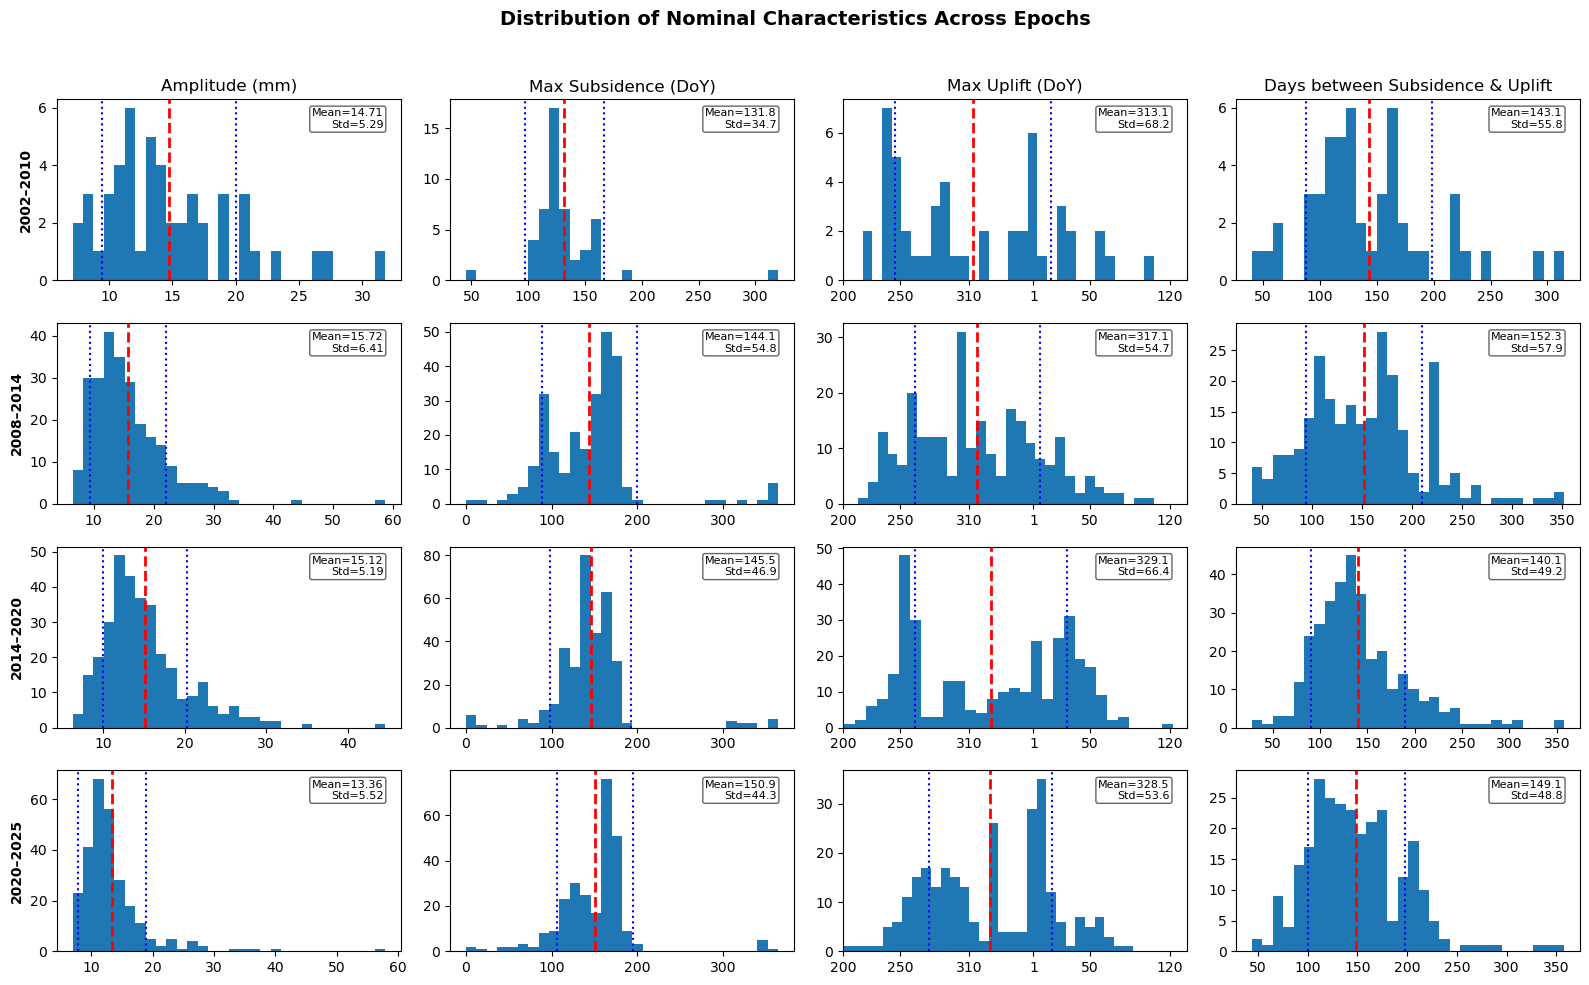

In [22]:
epochs = {
    "2002–2010": (2002, 2008),
    "2008–2014": (2008, 2014),
    "2014–2020": (2014, 2020),
    "2020–2025": (2020, 2025),
}

bins = 30

# Create a single figure with 4 columns (metrics) × N rows (epochs)
fig, axes = plt.subplots(len(epochs), 4, figsize=(16, 10), sharey=False)

# Loop through epochs
for row, (label, (start, end)) in enumerate(epochs.items()):
    # Filter data
    epoch_data = data[(data["year"] >= start) & (data["year"] <= end)].copy()
    if epoch_data.empty:
        continue
    
    # Shift Peak_DoY
    peak_doy_shifted = epoch_data['Peak_DoY'].apply(lambda x: x+365 if x < 165 else x)
    
    # ---- Amplitude ----
    ax = axes[row, 0]
    ax.hist(epoch_data['Amplitude'], bins=bins)
    mean_amp = epoch_data['Amplitude'].mean()
    std_amp = epoch_data['Amplitude'].std()
    ax.axvline(mean_amp, color="red", linestyle="--", linewidth=2)
    ax.axvline(mean_amp - std_amp, color="blue", linestyle=":", linewidth=1.5)
    ax.axvline(mean_amp + std_amp, color="blue", linestyle=":", linewidth=1.5)
    ax.set_title("Amplitude (mm)") if row == 0 else None
    ax.text(0.95, 0.95, f"Mean={mean_amp:.2f}\nStd={std_amp:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.6))
    
    # ---- Min_DoY ----
    ax = axes[row, 1]
    ax.hist(epoch_data['Min_DoY'], bins=bins)
    mean_min = epoch_data['Min_DoY'].mean()
    std_min = epoch_data['Min_DoY'].std()
    ax.axvline(mean_min, color="red", linestyle="--", linewidth=2)
    ax.axvline(mean_min - std_min, color="blue", linestyle=":", linewidth=1.5)
    ax.axvline(mean_min + std_min, color="blue", linestyle=":", linewidth=1.5)
    ax.set_title("Max Subsidence (DoY)") if row == 0 else None
    ax.text(0.95, 0.95, f"Mean={mean_min:.1f}\nStd={std_min:.1f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.6))
    
    # ---- Peak_DoY ----
    ax = axes[row, 2]
    ax.hist(peak_doy_shifted, bins=bins)
    mean_peak = peak_doy_shifted.mean()
    std_peak = peak_doy_shifted.std()
    ax.axvline(mean_peak, color="red", linestyle="--", linewidth=2)
    ax.axvline(mean_peak - std_peak, color="blue", linestyle=":", linewidth=1.5)
    ax.axvline(mean_peak + std_peak, color="blue", linestyle=":", linewidth=1.5)
    ax.set_xlim(200, 500)
    ax.set_xticks([200, 250, 310, 366, 415, 485])
    ax.set_xticklabels([200, 250, 310, 1, 50, 120])
    ax.set_title("Max Uplift (DoY)") if row == 0 else None
    ax.text(0.95, 0.95, f"Mean={mean_peak:.1f}\nStd={std_peak:.1f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.6))
    
    # ---- Time Min-to-Peak ----
    ax = axes[row, 3]
    ax.hist(epoch_data['Time_MintoPeak'], bins=bins)
    mean_time = epoch_data['Time_MintoPeak'].mean()
    std_time = epoch_data['Time_MintoPeak'].std()
    ax.axvline(mean_time, color="red", linestyle="--", linewidth=2)
    ax.axvline(mean_time - std_time, color="blue", linestyle=":", linewidth=1.5)
    ax.axvline(mean_time + std_time, color="blue", linestyle=":", linewidth=1.5)
    ax.set_title("Days between Subsidence & Uplift") if row == 0 else None
    ax.text(0.95, 0.95, f"Mean={mean_time:.1f}\nStd={std_time:.1f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.6))
    
    # Add row label
    axes[row, 0].set_ylabel(label, fontsize=10, weight="bold")

# Overall figure title
plt.suptitle("Distribution of Nominal Characteristics Across Epochs", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("Distribution3Epochs.png", dpi=300)
plt.show()


Using this trends, we still have multimodal distributions for Max Uplift (Doy). Amplitude seems to be more Gausian in exception for 2002-2010. Max subsidence also sees to be  normal. Overall, StDev didn't change significantly --> probably not a good way of binning the data.

#### Instead, Lets use a Grace MASCON and try to understand the variability at a more regional scale.

In [5]:
ds = xr.open_dataset("data/GraceTellus.nc")  # replace with your file path
lwe = ds["lwe_thickness"]  # (time, lat, lon)

countries = regionmask.defined_regions.natural_earth_v5_0_0.countries_50
greenland_idx = countries.map_keys("Greenland")
mask = countries.mask(lwe)

lwe_greenland = lwe.where(mask == greenland_idx)

lwe_greenland = lwe_greenland.assign_coords(
    lon=(((lwe_greenland.lon + 180) % 360) - 180)
)

# Ensure longitudes are sorted
lwe_greenland = lwe_greenland.sortby("lon")

GrISLWE = lwe_greenland.sel(lat=slice(60,85), lon=slice(-74, -14))
GrISLWE_mean = GrISLWE.mean(dim="time", skipna=True)

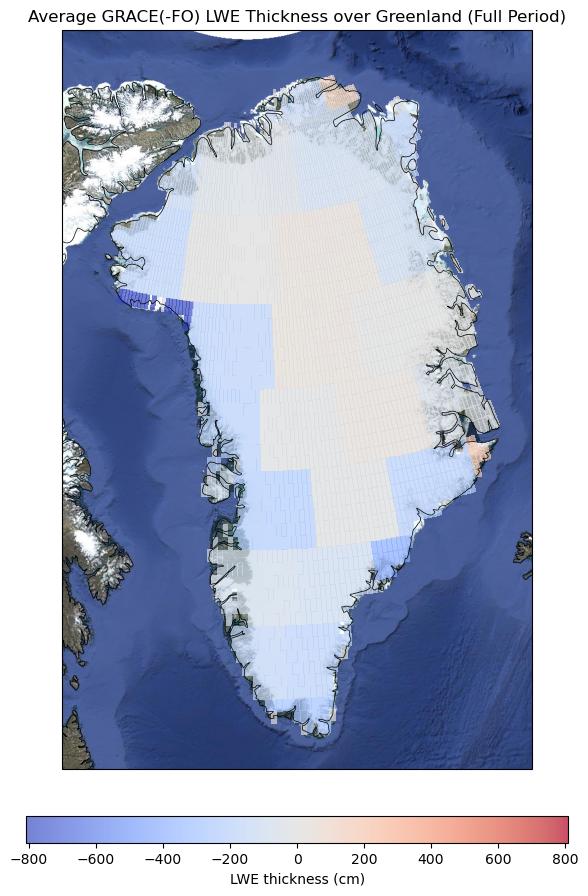

In [6]:
tiler = GoogleTiles(style="satellite")

# Create figure and axis
fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 12),
    subplot_kw={'projection': ccrs.Stereographic(central_longitude=-50)}
)

# Set extent (lon_min, lon_max, lat_min, lat_max)
extent = [-65, -27, 58, 85]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add satellite basemap
ax.add_image(tiler, 5)  # zoom level, try 5–7 depending on detail vs. speed

# Symmetric color scale
v = np.nanmax(np.abs(GrISLWE_mean.values))

# Plot data
pc = ax.pcolormesh(
    GrISLWE_mean.lon,
    GrISLWE_mean.lat,
    GrISLWE_mean,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    vmin=-v,
    vmax=v,
    alpha=0.7  # transparency so basemap shows underneath
)

# Coastlines and borders (optional since satellite already shows geography)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# Colorbar
cbar = plt.colorbar(pc, ax=ax, orientation="horizontal", pad=0.05, shrink=0.7)
cbar.set_label("LWE thickness (cm)")

# Title
plt.title("Average GRACE(-FO) LWE Thickness over Greenland (Full Period)")

plt.show()

In [7]:
fit = GrISLWE.polyfit(dim="time", deg=1, skipna=True)
trend = xr.polyval(GrISLWE["time"], fit.polyfit_coefficients)
GrISLWE_detrended = GrISLWE - trend

Now, I will group pixels by using kk-clustering to reduce the number of timeseries.

In [8]:
data = GrISLWE_detrended.stack(points=("lat", "lon"))  # dims -> (time, points)
X = data.transpose("points", "time").values  # shape = (n_points, n_time)

valid_mask = ~np.all(np.isnan(X), axis=1) & ~np.all(X == 0, axis=1)
X_valid = X[valid_mask]

imputer = SimpleImputer(strategy="mean")
X_filled = imputer.fit_transform(X_valid)

n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
labels_valid = kmeans.fit_predict(X_filled)

labels = np.full(X.shape[0], np.nan)  # fill everything with NaN
labels[valid_mask] = labels_valid     # assign cluster IDs only to valid points

clusters = xr.DataArray(
    labels,
    dims=["points"],
    coords={"points": data.points}
).unstack("points")

In [9]:
cluster_ids = np.unique(clusters.values[~np.isnan(clusters.values)])
n_clusters = len(cluster_ids)

colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))  # you can also use hsv, tab20b, etc.
cmap = mpcolors.ListedColormap(colors)


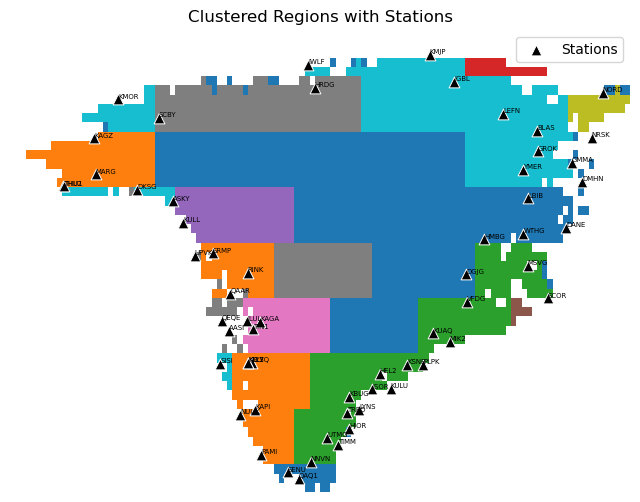

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
clusters.plot(ax=ax, cmap="tab10", add_colorbar=False)
ax.set_title("Clustered Regions with Stations")

ax.scatter(
    df_MetaData.lon,
    df_MetaData.lat,
    c="black", marker="^", s=60, edgecolor="white", linewidth=0.7,
    label="Stations"
)

for i, name in enumerate(df_MetaData.station):
    ax.text(
        df_MetaData.lon[i], df_MetaData.lat[i],
        name, fontsize=5, ha="left", va="bottom", color="black"
    )

ax.legend()
ax.axis("off")
plt.show()

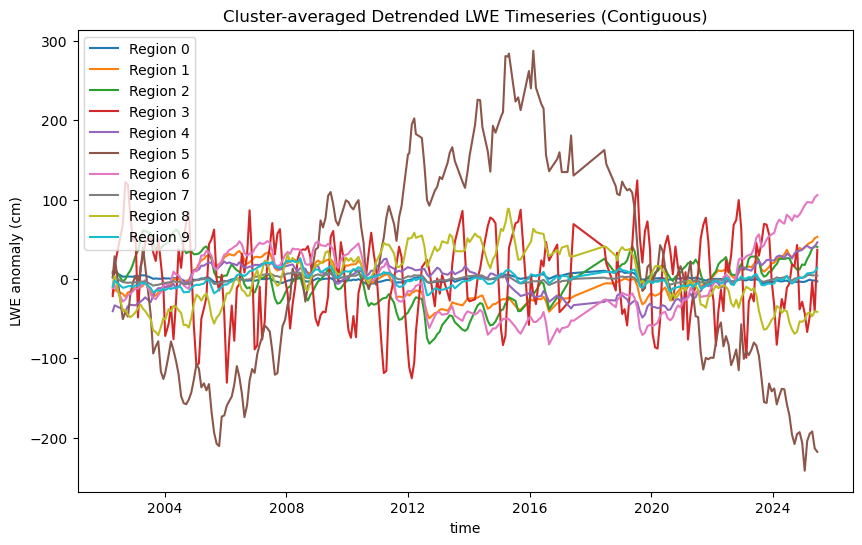

In [11]:
fig, ax = plt.subplots(figsize=(10,6))

for cid in np.unique(clusters.values[~np.isnan(clusters.values)]):
    mask = clusters == cid
    ts = GrISLWE_detrended.where(mask).mean(dim=["lat","lon"], skipna=True)
    ts.plot(ax=ax, label=f"Region {int(cid)}")

ax.set_title("Cluster-averaged Detrended LWE Timeseries (Contiguous)")
ax.set_ylabel("LWE anomaly (cm)")
ax.legend()
plt.show()

These regions behaves the most similarly when detrended. The more clusters we have, the more regions.  

The following part of the code forces the regions to be contigous, so for example, if a region is disconnected, it will break them and create two or more.

In [15]:
clusters_contig = clusters.copy()

next_label = 0
new_labels = np.full_like(clusters_contig.values, np.nan, dtype=float)

for c in np.unique(clusters.values[~np.isnan(clusters.values)]):
    mask = clusters.values == c
    labeled, ncomp = cc_label(mask)  # connected components
    
    for comp_id in range(1, ncomp+1):
        new_labels[labeled == comp_id] = next_label
        next_label += 1

clusters_contig.values = new_labels

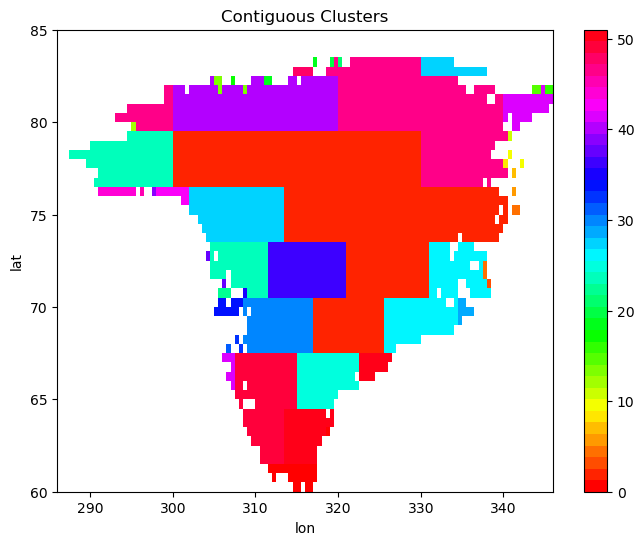

In [ ]:

colors_40 = plt.cm.hsv(np.linspace(0, 1, 40))

cmap_40 = mpcolors.ListedColormap(colors_40)

plt.figure(figsize=(8,6))
clusters_contig.plot(cmap=cmap_40)
plt.title("Contiguous Clusters")
plt.show()

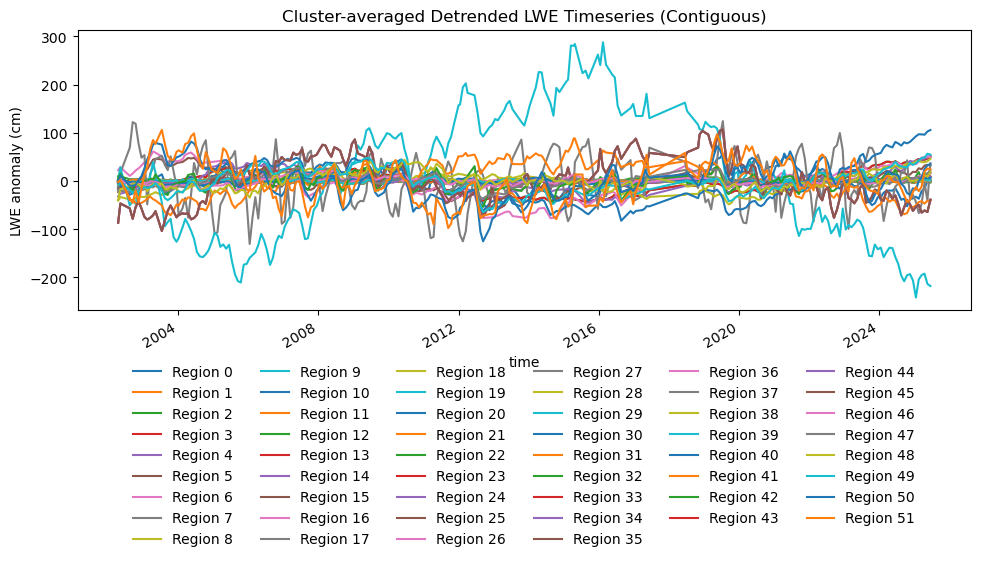

In [218]:
fig, ax = plt.subplots(figsize=(10,6))

for cid in np.unique(clusters_contig.values[~np.isnan(clusters_contig.values)]):
    mask = clusters_contig == cid
    ts = GrISLWE_detrended.where(mask).mean(dim=["lat","lon"], skipna=True)
    ts.plot(ax=ax, label=f"Region {int(cid)}")

ax.set_title("Cluster-averaged Detrended LWE Timeseries (Contiguous)")
ax.set_ylabel("LWE anomaly (cm)")

# Move legend below the plot
ax.legend(
    loc="upper center",        # put it above the x-axis
    bbox_to_anchor=(0.5, -0.15),  # center below the plot
    ncol=6,                   # number of columns (adjust depending on clusters)
    frameon=False
)

plt.tight_layout()
plt.show()

Breaking the regions into contigous parts doesn't seem to show much differences in the region behaviors.